# Stage 2: Random Forest

Train and evaluate a RandomForestClassifier using the prepared train/val/test splits.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from sklearn.ensemble import RandomForestClassifier

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from second_stage.metrics import compute_metrics, show_confusion, plot_confusion

In [2]:
splits_dir = PROJECT_ROOT / "second_stage" / "splits"
train_path = splits_dir / "train.csv"
val_path = splits_dir / "val.csv"
test_path = splits_dir / "test.csv"

for p in [train_path, val_path, test_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing split file: {p}")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

target_col = "loan_status"

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (28800, 22) Val: (7200, 22) Test: (9000, 22)


In [3]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

print("Train accuracy (sklearn):", model.score(X_train, y_train))
print("Val accuracy (sklearn):", model.score(X_val, y_val))

Train accuracy (sklearn): 1.0
Val accuracy (sklearn): 0.9126388888888889


In [4]:
def eval_split(name: str, X, y):
    preds = model.predict(X)
    metrics = compute_metrics(y, preds, positive_label=1)
    metrics["split"] = name
    return metrics

results = pd.DataFrame([
    eval_split("train", X_train, y_train),
    eval_split("val", X_val, y_val),
    eval_split("test", X_test, y_test),
]).set_index("split")

display(results.round(4))

,accuracy,precision,recall,f1,specificity
split,,,,,
train,1.0000,1.0000,1.0000,1.0000,1.0000
val,0.9126,0.8715,0.7119,0.7836,0.9700
test,0.9152,0.8778,0.7185,0.7902,0.9714


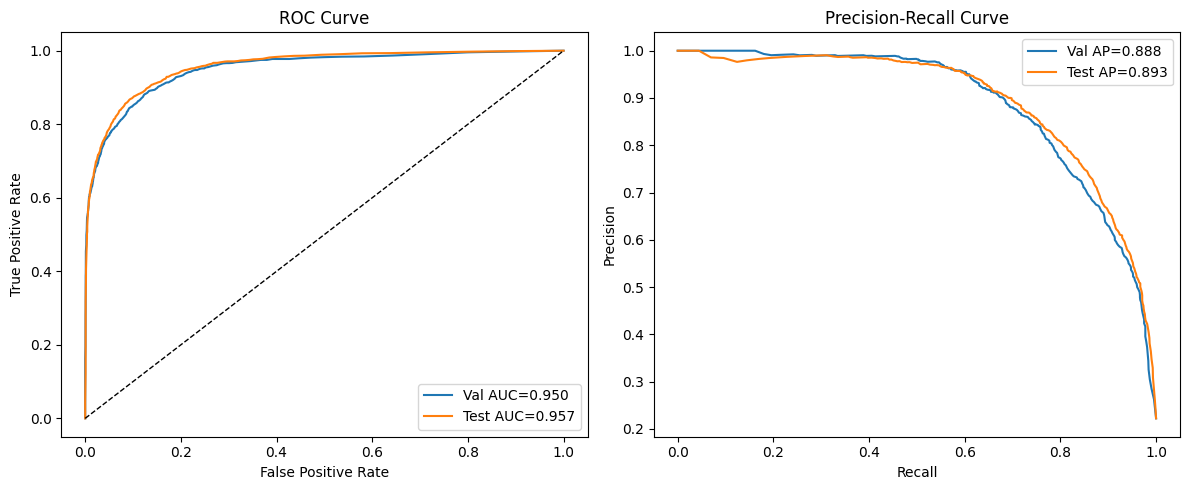

,accuracy,precision,recall,f1,specificity
threshold,,,,,
0.45,0.9133,0.8461,0.7456,0.7927,0.9612
0.40,0.9108,0.8202,0.7669,0.7926,0.9520
0.35,0.9031,0.7717,0.8006,0.7859,0.9323
0.50,0.9126,0.8715,0.7119,0.7836,0.9700
0.30,0.8943,0.7276,0.8381,0.7790,0.9104
0.55,0.9122,0.8987,0.6819,0.7754,0.9780
0.60,0.9097,0.9152,0.6544,0.7631,0.9827
0.25,0.8782,0.6742,0.8744,0.7614,0.8793
0.65,0.9065,0.9352,0.6225,0.7475,0.9877


Best threshold by F1 (val): 0.45


,accuracy,precision,recall,f1,specificity
test_at_best_threshold,0.9164,0.8541,0.7525,0.8001,0.9633


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ROC/PR curves
val_proba = model.predict_proba(X_val)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

fpr_val, tpr_val, _ = roc_curve(y_val, val_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)
roc_auc_val = auc(fpr_val, tpr_val)
roc_auc_test = auc(fpr_test, tpr_test)

prec_val, rec_val, _ = precision_recall_curve(y_val, val_proba)
prec_test, rec_test, _ = precision_recall_curve(y_test, test_proba)
ap_val = average_precision_score(y_val, val_proba)
ap_test = average_precision_score(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr_val, tpr_val, label=f"Val AUC={roc_auc_val:.3f}")
axes[0].plot(fpr_test, tpr_test, label=f"Test AUC={roc_auc_test:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(rec_val, prec_val, label=f"Val AP={ap_val:.3f}")
axes[1].plot(rec_test, prec_test, label=f"Test AP={ap_test:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

# Threshold tuning on validation set
thresholds = np.arange(0.1, 0.91, 0.05)
rows = []
for t in thresholds:
    val_pred = (val_proba >= t).astype(int)
    metrics = compute_metrics(y_val, val_pred, positive_label=1)
    metrics["threshold"] = float(np.round(t, 2))
    rows.append(metrics)

threshold_table = pd.DataFrame(rows).set_index("threshold").sort_values("f1", ascending=False)
display(threshold_table.round(4))

best_threshold = threshold_table.index[0]
print(f"Best threshold by F1 (val): {best_threshold}")

test_pred = (test_proba >= best_threshold).astype(int)
test_metrics = compute_metrics(y_test, test_pred, positive_label=1)
display(pd.DataFrame([test_metrics], index=["test_at_best_threshold"]).round(4))

Confusion matrix: val


,pred_0,pred_1
actual_0,5432,168
actual_1,461,1139


Confusion matrix: test


,pred_0,pred_1
actual_0,6800,200
actual_1,563,1437


<Axes: title={'center': 'Test Confusion Matrix'}, xlabel='Predicted', ylabel='Actual'>

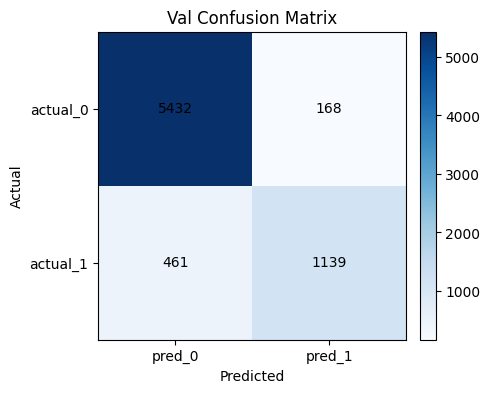

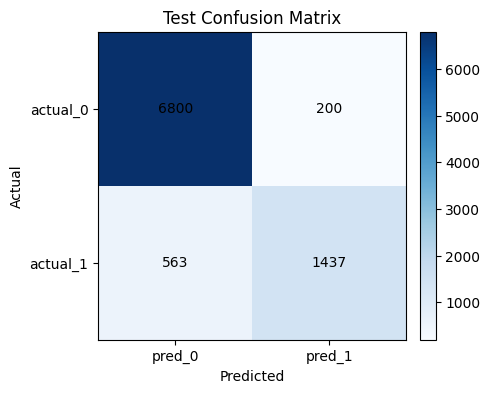

In [6]:
display(show_confusion(y_val, model.predict(X_val), title="val"))
display(show_confusion(y_test, model.predict(X_test), title="test"))

plot_confusion(y_val, model.predict(X_val), title="Val Confusion Matrix")
plot_confusion(y_test, model.predict(X_test), title="Test Confusion Matrix")